### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

#### LEGGENDA

- **pd.read_csv("url")** → Carica un file CSV da un URL in un DataFrame.

- **df.rename(columns={...})** → Rinomina una o più colonne.

- **df.nlargest(n, "colonna")** → Restituisce le n righe con i valori più alti nella colonna specificata.

- **df["colonna"].mean()** → Calcola la media aritmetica di una colonna.

- **df["nuova_colonna"] = (df["a"] + df["b"]) / 3** → Crea una nuova colonna con il risultato di un'espressione.

- **df.loc[df["colonna"].idxmax()]** → Trova la riga corrispondente al valore massimo di una colonna.

- **df[df["colonna"] > soglia]** → Filtra le righe in base a una condizione booleana.

- **.head(10)** → Mostra solo le prime 10 righe (utile per evitare output troppo lunghi).

- **.to_string(index=False)** → Stampa il DataFrame senza l'indice, più leggibile.

- **plt.bar(x, y)** → Grafico a barre verticali.

- **plt.plot(x, y, marker="o")** → Grafico a linee con marcatori circolari.

- **plt.xticks(rotation=45)** → Ruota le etichette dell'asse x di 45 gradi.

- **plt.xticks([])** → Rimuove le etichette dell'asse x (utile quando sono troppe).

- **plt.tight_layout()** → Regola automaticamente i margini per evitare sovrapposizioni.

- **plt.show()** → Visualizza il grafico.

### 1. CELLA DEI CALCOLI

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Carico il dataset
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

# Rinomino le colonne in italiano
df.rename(columns={
    "country": "paese",
    "beer_servings": "porzioni_birra",
    "spirit_servings": "porzioni_distillati",
    "wine_servings": "porzioni_vino",
    "total_litres_of_pure_alcohol": "totale_litri_alcol_puro"
}, inplace=True)

# 1. Visualizzo i primi 10 paesi (dal più alto)
top10_alcol = df.nlargest(10, "totale_litri_alcol_puro")[["paese", "totale_litri_alcol_puro"]]

# 2. Media di birra, vino e distillati
media_birra = df["porzioni_birra"].mean()
media_vino = df["porzioni_vino"].mean()
media_distillati = df["porzioni_distillati"].mean()

# 3. Creo la nuova colonna alcohol_index
df["indice_alcol"] = (df["porzioni_birra"] + df["porzioni_vino"] + df["porzioni_distillati"]) / 3

# 4. Paese con alcohol_index massimo
max_index_row = df.loc[df["indice_alcol"].idxmax()]
paese_max_indice = max_index_row["paese"]
valore_max_indice = max_index_row["indice_alcol"]

# 5. Paesi che consumano più di 100 birre all'anno
birre_100 = df[df["porzioni_birra"] > 100][["paese", "porzioni_birra"]]

# Print finali
print("Top 10 paesi per totale alcol puro (litri):")
print(top10_alcol.to_string(index=False), "\n")

print(f"Media consumi: birra = {media_birra:.1f}, vino = {media_vino:.1f}, distillati = {media_distillati:.1f}\n")

print(f"Paese con indice alcol massimo: {paese_max_indice} ({valore_max_indice:.1f})\n")

print("Paesi con consumo di birra > 100 (prime 10 righe):")
print(birre_100.head(10).to_string(index=False))




Top 10 paesi per totale alcol puro (litri):
             paese  totale_litri_alcol_puro
           Belarus                     14.4
         Lithuania                     12.9
           Andorra                     12.4
           Grenada                     11.9
    Czech Republic                     11.8
            France                     11.8
Russian Federation                     11.5
           Ireland                     11.4
        Luxembourg                     11.4
          Slovakia                     11.4 

Media consumi: birra = 106.2, vino = 49.5, distillati = 81.0

Paese con indice alcol massimo: Andorra (231.7)

Paesi con consumo di birra > 100 (prime 10 righe):
            paese  porzioni_birra
          Andorra             245
           Angola             217
Antigua & Barbuda             102
        Argentina             193
        Australia             261
          Austria             279
          Bahamas             122
         Barbados             143
  

### 2. CELLE DEI GRAFICI

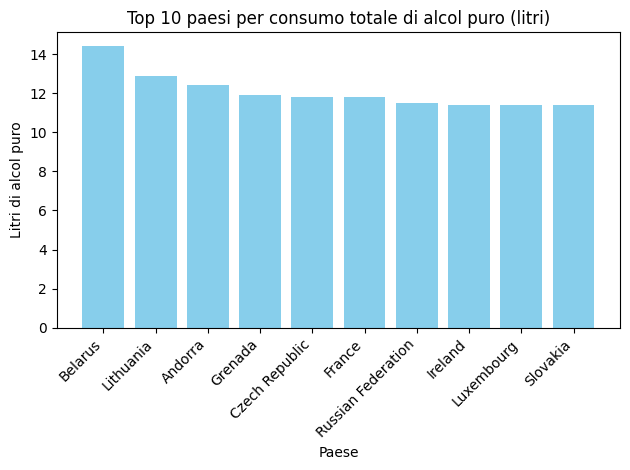

In [ ]:
# Bar chart: 10 paesi con più totale_litri_alcol_puro
top10 = df.nlargest(10, "totale_litri_alcol_puro")                  # Seleziono i primi 10 paesi di alcol puro
plt.Figure(figsize=(10, 6))                                         # Creo la figura
plt.bar(top10["paese"],                                             # Grafico a barre
        top10["totale_litri_alcol_puro"], 
        color="skyblue")                                            # Colore barre
plt.title("Top 10 paesi per consumo totale di alcol puro (litri)")  # Titolo
plt.xlabel("Paese")                                                 # Etichetta asse X
plt.ylabel("Litri di alcol puro")                                   # Etichetta asse Y
plt.xticks(rotation=45, ha="right")                                 # Ruota etichette asse X di 45 gradi
plt.tight_layout()                                                  # Adatta automaticamente elementi per evitare sovrapposizioni
plt.show()

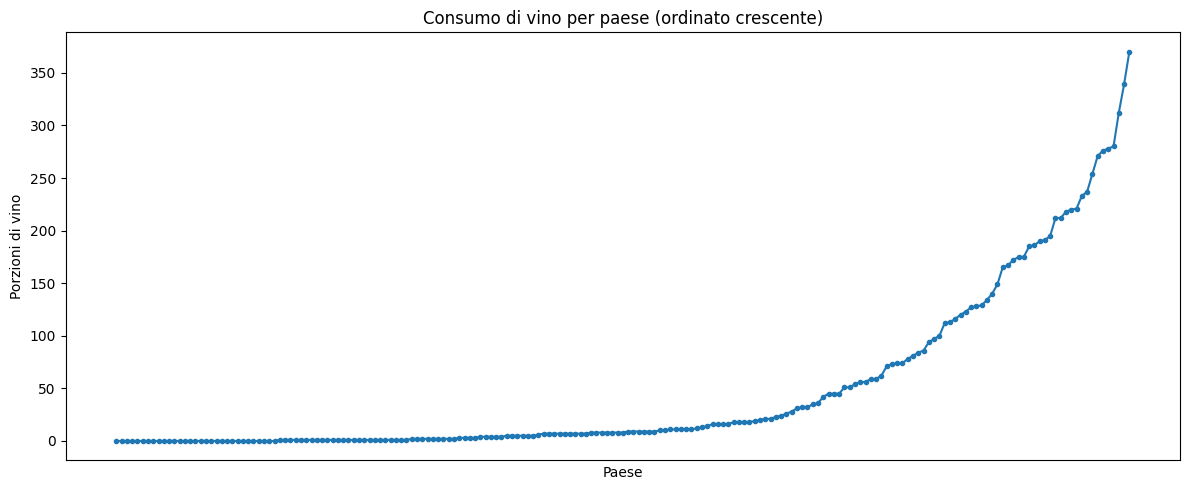

In [ ]:
# Line plot: porzioni_vino ordinato per paese
df_sorted = df.sort_values("porzioni_vino")                     # Ordina il Dataframe 
plt.figure(figsize=(12,5))                                      # Larghezza figura
plt.plot(df_sorted["paese"],                                    
         df_sorted["porzioni_vino"], 
         marker="o",                                            # Aggiunge un pallino su ogni punto
         linestyle="-",                                         # Linea continua
         markersize=3)                                          # Grandezza del punto
plt.title("Consumo di vino per paese (ordinato crescente)")
plt.xlabel("Paese")
plt.ylabel("Porzioni di vino")
plt.xticks([])                                                  # Nasconde le etichette dell'asse X (troppi paesi)
plt.tight_layout()
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

## 1. CELLA DEI CALCOLI

#### LEGGENDA
- **groupby("job_country")["salary_year_avg"].mean()** → Calcola la media degli stipendi per ogni paese.

- **.reset_index()** →Trasforma l'indice del gruppo in una colonna normale.

- **.rename(columns={...})** → Rinomina le colonne con nomi italiani.

- **.size()** → Conta il numero di righe per ogni gruppo (numero di offerte).

- **.merge()** → Unisce più DataFrame sulla colonna comune job_country.

- **.groupby("job_title_short")["salary_year_avg"].mean()** → Stipendio medio per titolo di lavoro.

- **.sort_values(ascending=True)** → Ordine crescente (per il grafico a barre orizzontale, il più alto in alto).

- **.plot.barh()** → Grafico a barre orizzontali.

- **plt.title()**, **plt.xlabel()**, **plt.ylabel()** → Titolo ed etichette assi.

- **plt.tight_layout()** → Evita che etichette vengano tagliate.

- **plt.show()** → Visualizza il grafico.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Carico il dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


# 1. Stipendio medio annuale per paese
media_salario = df.groupby("job_country")["salary_year_avg"].mean().reset_index()
media_salario.rename(columns={"salary_year_avg": "stipendio_medio"}, inplace=True)

# 2. Numero totale di offerte per paese
conteggio_offerte = df.groupby("job_country").size().reset_index(name="numero_offerte")


# 3. Minimo e massimo stipendio per paese
min_salario = df.groupby("job_country")["salary_year_avg"].min().reset_index(name="stipendio_min")
max_salario = df.groupby("job_country")["salary_year_avg"].max().reset_index(name="stipendio_max")

# Unione dei riepiloghi
riepilogo_paesi = media_salario.merge(conteggio_offerte, on="job_country")
riepilogo_paesi = riepilogo_paesi.merge(min_salario, on="job_country")
riepilogo_paesi = riepilogo_paesi.merge(max_salario, on="job_country")

# 4. Stipendio medio per titolo di lavoro (per il grafico)
stipendi_per_titolo = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=True)

# Print finali
print("Riepilogo per paese (media stipendio, numero offerte, min, max) – prime 10 righe:\n")
print(riepilogo_paesi.head(10).to_string(index=False))

Riepilogo per paese (media stipendio, numero offerte, min, max) – prime 10 righe:

job_country  stipendio_medio  numero_offerte  stipendio_min  stipendio_max
Afghanistan              NaN              16            NaN            NaN
    Albania     79472.500000             119        43200.0       157500.0
    Algeria     44550.000000             111        44100.0        45000.0
     Angola              NaN              11            NaN            NaN
  Argentina    105212.343750            8736        45000.0       222000.0
    Armenia     78757.000000             289        45000.0       128682.0
  Australia    118987.574324           12955        20000.0       257500.0
    Austria    105269.194444            9710        53014.0       165000.0
 Azerbaijan     72000.000000              83        72000.0        72000.0
    Bahamas    201511.619048              69       173500.0       284016.0


## 2. CELLA DEI GRAFICI

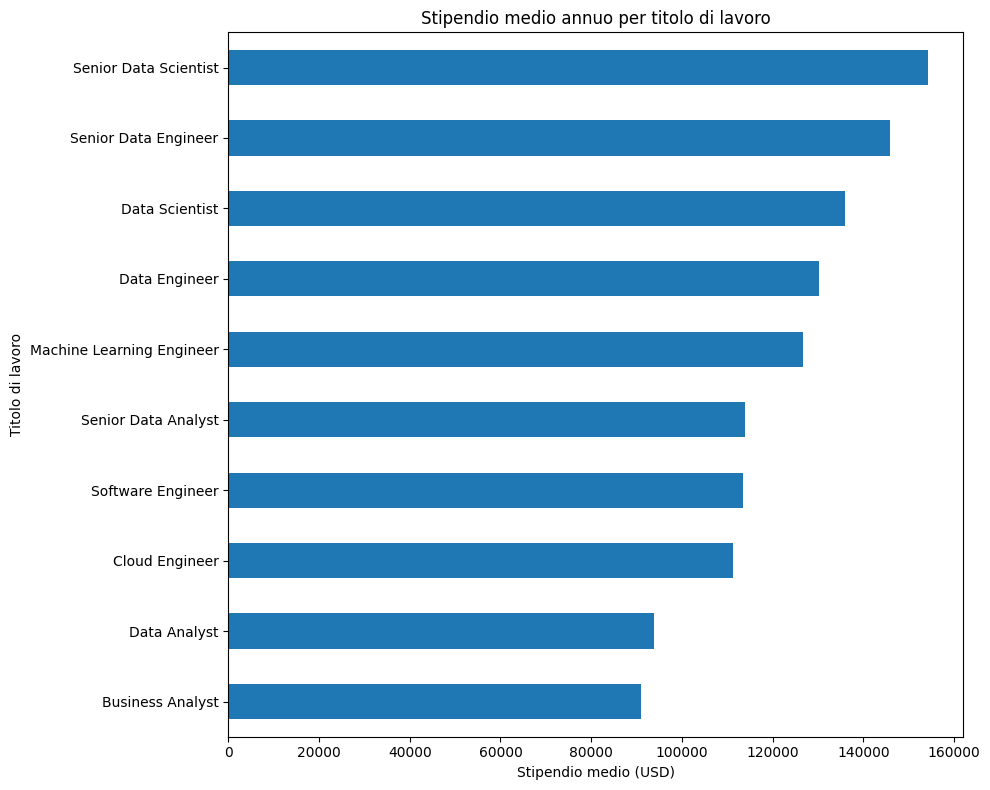

In [14]:
# Grafico a barre orizzontali
plt.figure(figsize=(10, 8))
stipendi_per_titolo.plot.barh()
plt.title("Stipendio medio annuo per titolo di lavoro")
plt.xlabel("Stipendio medio (USD)")
plt.ylabel("Titolo di lavoro")
plt.tight_layout()
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

## 1. CELLA DEI CALCOLI

#### LEGGENDA
- **groupby("day")** → Raggruppa per giorno.

- **.agg(...)** → Applica più funzioni aggregate in una volta.

- **reset_index()** → Trasforma l'indice (day) in colonna normale.

- **idxmax()** → Restituisce l'indice del valore massimo.

- **.sort_values("conto_medio", ascending=False)** → Ordina dal più alto al più basso per il grafico.

- **plt.bar()** → Grafico a barre verticali.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Carico il dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# 1. Statistiche per giorno (conto medio, conteggio, min, max)
raggruppato = df.groupby("day").agg(
    conto_medio=("total_bill", "mean"),
    numero_osservazioni=("total_bill", "count"),
    conto_min=("total_bill", "min"),
    conto_max=("total_bill", "max")
).reset_index()

# 2. Nuova colonna: conto per persona
df["conto_per_persona"] = df["total_bill"] / df["size"]

# 3. Giorno con conto medio più alto
giorno_max_conto = raggruppato.loc[raggruppato["conto_medio"].idxmax(), "day"]

# 4. Dati per grafico a barre (conto medio per giorno, ordinato decrescente)
raggruppato_ordinato = raggruppato.sort_values("conto_medio", ascending=False)

# Print finali
print("Statistiche per giorno:\n")
print(raggruppato.to_string(index=False), "\n")

print(f"Giorno con conto medio più alto: {giorno_max_conto}\n")


Statistiche per giorno:

 day  conto_medio  numero_osservazioni  conto_min  conto_max
 Fri    17.151579                   19       5.75      40.17
 Sat    20.441379                   87       3.07      50.81
 Sun    21.410000                   76       7.25      48.17
Thur    17.682742                   62       7.51      43.11 

Giorno con conto medio più alto: Sun



## 2. CELLA DEI GRAFICI

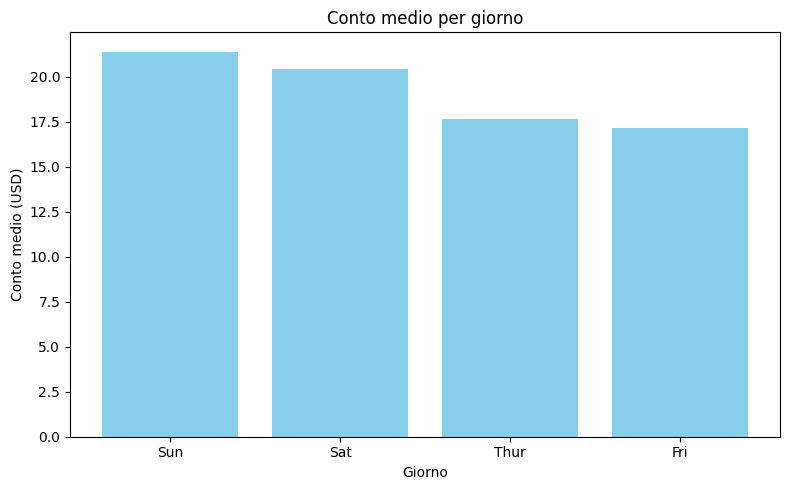

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(raggruppato_ordinato["day"], 
        raggruppato_ordinato["conto_medio"], 
        color="skyblue")
plt.title("Conto medio per giorno")
plt.xlabel("Giorno")
plt.ylabel("Conto medio (USD)")
plt.tight_layout()
plt.show()